# 1. Load London EPC Dataset

In [1]:
from pathlib import Path
import pandas as pd

base_dir = Path("/Users/pitzsb1/Documents/all-domestic-certificates")

# London 폴더만 탐색
csv_files = list(base_dir.rglob("*London*/*.csv"))

dfs = []

for file in csv_files:
    try:
        df = pd.read_csv(file, low_memory=False)
        dfs.append(df)
    except:
        pass

epc_london = pd.concat(dfs, ignore_index=True)
print(epc_london.shape)

(22724, 99)


# 2. Select Variables for Analysis

In [3]:
cols = [
    "UPRN",
    "CURRENT_ENERGY_RATING",
    "CURRENT_ENERGY_EFFICIENCY",
    "TOTAL_FLOOR_AREA",
    "CO2_EMISSIONS_CURRENT",
    "PROPERTY_TYPE",
    "BUILT_FORM",
    "CONSTRUCTION_AGE_BAND",
    "TENURE",
    "MAINHEAT_DESCRIPTION",
    "LODGEMENT_DATE"
]

df = epc_london[cols].copy()
df.shape

(22724, 11)

In [4]:
df["CURRENT_ENERGY_RATING"].value_counts()

CURRENT_ENERGY_RATING
C    3762
B    2183
D    2129
E     826
F     209
G     100
A       8
Name: count, dtype: int64

# 3. Filter Repeated Building Records by UPRN

In [5]:
df.isna().sum().sort_values(ascending=False)

UPRN                         14496
TENURE                       13651
CONSTRUCTION_AGE_BAND        13612
MAINHEAT_DESCRIPTION         13508
CURRENT_ENERGY_RATING        13507
CURRENT_ENERGY_EFFICIENCY    13507
TOTAL_FLOOR_AREA             13507
CO2_EMISSIONS_CURRENT        13507
PROPERTY_TYPE                13507
BUILT_FORM                   13507
LODGEMENT_DATE               13507
dtype: int64

UPRN(건물 고유 아이디) -> 중복된 아이디 중 등급 다른 건물 있나 체크

In [6]:
# UPRN 결측치 제거

df = df.dropna(subset=["UPRN"])
df.shape

(8228, 11)

In [7]:
# UPRN 등장 빈도 확인

df["UPRN"].value_counts().head()

UPRN
1.000236e+11    18
2.000001e+11    11
9.551248e+07     9
1.000229e+11     6
1.000229e+11     6
Name: count, dtype: int64

In [8]:
# UPRN이 2회 이상 등장하는 경우 확인

uprn_counts = df["UPRN"].value_counts()

multi_uprn = uprn_counts[uprn_counts >= 2].index

df_multi = df[df["UPRN"].isin(multi_uprn)].copy()
df_multi.shape

(4786, 11)

# 4. Measure Rating Inconsistency

In [9]:
# 등급 A, B, C, D, E, F, G 순으로 1~7로 매핑

rating_map = {
    "A": 7,
    "B": 6,
    "C": 5,
    "D": 4,
    "E": 3,
    "F": 2,
    "G": 1
}

df_multi["rating_score"] = df_multi["CURRENT_ENERGY_RATING"].map(rating_map)
df_multi.head()

,UPRN,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,TOTAL_FLOOR_AREA,CO2_EMISSIONS_CURRENT,PROPERTY_TYPE,BUILT_FORM,CONSTRUCTION_AGE_BAND,TENURE,MAINHEAT_DESCRIPTION,LODGEMENT_DATE,rating_score
13508,9.550062e+07,C,80.0,55.00,1.8,Flat,Mid-Terrace,England and Wales: 2003-2006,rental (private),"Room heaters, electric",2020-07-19,5
13509,9.550054e+07,C,69.0,50.86,2.0,Maisonette,Enclosed End-Terrace,England and Wales: 1996-2002,rental (private),"Room heaters, electric",2009-03-20,5
13510,2.000001e+11,F,36.0,40.00,3.8,Flat,Mid-Terrace,England and Wales: 1967-1975,rental (private),"Room heaters, electric",2019-07-10,2
13515,1.000200e+11,C,77.0,70.26,2.2,Flat,Mid-Terrace,England and Wales: 1996-2002,owner-occupied,Community scheme,2010-05-28,5
13518,9.551472e+07,B,82.0,100.00,1.0,Flat,Detached,NO DATA!,owner-occupied,Community scheme,2018-03-16,6


In [10]:
# 같은 건물에서의 등급 변화 확인
# UPRN별로 최소 등급과 최대 등급을 계산하여 등급 변화가 있는지 확인

change = df_multi.groupby("UPRN").agg(
    rating_min=("rating_score", "min"),
    rating_max=("rating_score", "max")
)

change["rating_gap"] = change["rating_max"] - change["rating_min"]

change.head()

,rating_min,rating_max,rating_gap
UPRN,,,
95500444.0,5,5,0
95500449.0,4,5,1
95500450.0,4,5,1
95500452.0,5,6,1
95500453.0,5,6,1


In [11]:
# 등급 변화가 있는 경우와 없는 경우의 빈도 확인

change["rating_gap"].value_counts().sort_index()

rating_gap
0    1008
1     856
2     256
3      64
4       9
5       2
Name: count, dtype: int64

# 5. Analyze Inconsistent Rating Cases

In [12]:
# 이상 건물 개수 확인

(change["rating_gap"] >= 2).sum()

np.int64(331)

In [13]:
# 이상 건물 비율 확인

total = len(change)
weird = (change["rating_gap"] >= 2).sum()

weird / total

np.float64(0.15079726651480638)

동일 건물에 대해 약 15%의 사례에서 2단계 이상의 에너지 등급 변화가 발생

In [14]:
# 이상 건물 따로 체크

weird_uprn = change[change["rating_gap"] >= 2].index

df_weird = df_multi[df_multi["UPRN"].isin(weird_uprn)]
df_weird.shape

(779, 12)

In [15]:
# effciency 변화 확인

eff_change = df_weird.groupby("UPRN").agg(
    eff_min=("CURRENT_ENERGY_EFFICIENCY", "min"),
    eff_max=("CURRENT_ENERGY_EFFICIENCY", "max")
)

eff_change["eff_gap"] = eff_change["eff_max"] - eff_change["eff_min"]

eff_change.head()

,eff_min,eff_max,eff_gap
UPRN,,,
95500523.0,63.0,83.0,20.0
95500525.0,39.0,79.0,40.0
95500526.0,48.0,77.0,29.0
95500535.0,52.0,69.0,17.0
95500544.0,41.0,79.0,38.0


In [16]:
# 요약 통계

eff_change["eff_gap"].describe()

count    331.000000
mean      30.939577
std       12.168612
min       13.000000
25%       22.000000
50%       29.000000
75%       38.000000
max       78.000000
Name: eff_gap, dtype: float64

동일 건물에서 평균 약 30 이상의 에너지 효율 점수 변동이 발생 -> 2단계 이상의 등급 변화로 이어질 수 있는 수준

In [17]:
# 참고: 면적도 변화가 있는지 확인

area_change = df_weird.groupby("UPRN").agg(
    area_min=("TOTAL_FLOOR_AREA", "min"),
    area_max=("TOTAL_FLOOR_AREA", "max")
)

area_change["area_gap"] = area_change["area_max"] - area_change["area_min"]

area_change["area_gap"].describe()

count    331.000000
mean       6.678701
std       12.451173
min        0.000000
25%        0.955000
50%        2.500000
75%        7.050000
max      122.000000
Name: area_gap, dtype: float64

건물 자체는 거의 안 변함. 면적 안정 ✔ 구조 거의 동일 ✔

-> 동일 건물에 대해 물리적 특성(면적)은 상대적으로 안정적인 반면, 에너지 효율 점수는 큰 폭으로 변동하며, 이러한 점수 변동이 등급 변화의 주요 원인으로 작용

# 6. Visualization

# 7. Modeling

In [34]:
# 모델용 데이터 만들기

model_cols = [
    "CURRENT_ENERGY_RATING",
    "CURRENT_ENERGY_EFFICIENCY", 
    "TOTAL_FLOOR_AREA",
    "CO2_EMISSIONS_CURRENT",
    "PROPERTY_TYPE",
    "BUILT_FORM",
    "CONSTRUCTION_AGE_BAND",
    "TENURE",
    "MAINHEAT_DESCRIPTION"
]

model_df = df.dropna(subset=model_cols).copy()

model_df.shape

(7985, 11)

In [ ]:
# X, Y 분리

X = model_df.drop(columns=["CURRENT_ENERGY_RATING", "UPRN", "LODGEMENT_DATE"])
y = model_df["CURRENT_ENERGY_RATING"]

X.shape, y.shape

((7985, 8), (7985,))

In [24]:
# 범주형 변수 확인

cat_features = X.select_dtypes(include="object").columns.tolist()
cat_features

['PROPERTY_TYPE',
 'BUILT_FORM',
 'CONSTRUCTION_AGE_BAND',
 'TENURE',
 'MAINHEAT_DESCRIPTION']

범주형 변수 있으니 CatBoost 완전 적합. (문자열 그대로 처리 가능)

In [25]:
# train, test 분리

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
# catboost 모델 학습

from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function="MultiClass",
    verbose=100,
    random_seed=42
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

0:	learn: 1.4275224	total: 89.3ms	remaining: 26.7s
100:	learn: 0.0039708	total: 2.97s	remaining: 5.86s
200:	learn: 0.0009388	total: 6.08s	remaining: 3s
299:	learn: 0.0004932	total: 9.16s	remaining: 0us


CatBoostClassifier(depth=6, iterations=300, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=100)

In [33]:
# 성능 확인

from sklearn.metrics import accuracy_score, classification_report

pred = model.predict(X_test)

accuracy_score(y_test, pred)

1.0

1.0? leakage 생김

In [35]:
# 정답 컬럼 or 의심 컬럼 드랍

X_no_leak = model_df.drop(columns=[
    "CURRENT_ENERGY_RATING",
    "CURRENT_ENERGY_EFFICIENCY",
    "UPRN",
    "LODGEMENT_DATE"
])

y = model_df["CURRENT_ENERGY_RATING"]

cat_features_no_leak = X_no_leak.select_dtypes(include="object").columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X_no_leak,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
# 재학습

model2 = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function="MultiClass",
    verbose=100,
    random_seed=42
)

model2.fit(
    X_train,
    y_train,
    cat_features=cat_features_no_leak
)

0:	learn: 1.7573862	total: 20.4ms	remaining: 6.11s
100:	learn: 0.6496780	total: 3.43s	remaining: 6.75s
200:	learn: 0.5445040	total: 7.33s	remaining: 3.61s
299:	learn: 0.4898737	total: 10.7s	remaining: 0us


CatBoostClassifier(depth=6, iterations=300, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=100)

In [37]:
# 성능 확인

from sklearn.metrics import accuracy_score, classification_report

pred = model2.predict(X_test)

accuracy_score(y_test, pred)

0.7207263619286162

In [38]:
# 모델이 보기에 이상한(틀린) 케이스 체크

pred2 = model2.predict(X_test).ravel()

result = X_test.copy()
result["actual"] = y_test.values
result["pred"] = pred2
result["match"] = result["actual"] == result["pred"]

result[result["match"] == False].head(20)

,TOTAL_FLOOR_AREA,CO2_EMISSIONS_CURRENT,PROPERTY_TYPE,BUILT_FORM,CONSTRUCTION_AGE_BAND,TENURE,MAINHEAT_DESCRIPTION,actual,pred,match
19364,60.00,2.0,Flat,Mid-Terrace,NO DATA!,unknown,"Air source heat pump, warm air, electric",D,C,False
15506,109.00,6.3,Flat,Detached,England and Wales: 1967-1975,rental (social),Electric underfloor heating,D,E,False
20775,60.00,0.8,Flat,Mid-Terrace,2021,Not defined - use in the case of a new dwellin...,Community scheme,C,B,False
20632,112.00,5.4,Flat,End-Terrace,England and Wales: before 1900,Rented (private),"Boiler and radiators, mains gas",E,D,False
21095,52.00,1.4,Flat,Mid-Terrace,England and Wales: 2007-2011,Rented (private),Community scheme,C,B,False
18402,70.00,3.7,Flat,Mid-Terrace,England and Wales: 1967-1975,rental (social),Electric underfloor heating,C,D,False
19799,37.00,2.1,Flat,Mid-Terrace,England and Wales: 1900-1929,owner-occupied,"Room heaters, electric",C,D,False
15416,118.00,2.6,Flat,Detached,NO DATA!,unknown,"Boiler and radiators, electric",C,D,False
17045,66.00,1.8,Flat,Enclosed Mid-Terrace,England and Wales: 1996-2002,Rented (private),"Electric storage heaters, Electric storage hea...",B,C,False
22097,68.00,2.3,Flat,Mid-Terrace,England and Wales: 1967-1975,Owner-occupied,Community scheme,D,C,False


EPC 등급은 전반적으로 건물 특성과 일관된 패턴을 보이지만, 일부 건물에서는 모델 예측과 실제 등급 간 불일치가 발생함

In [39]:
# 피쳐 중요도 확인

import pandas as pd

importance = pd.DataFrame({
    "feature": X_no_leak.columns,
    "importance": model2.get_feature_importance()
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance

,feature,importance
1,CO2_EMISSIONS_CURRENT,39.154661
6,MAINHEAT_DESCRIPTION,14.978905
0,TOTAL_FLOOR_AREA,14.370838
4,CONSTRUCTION_AGE_BAND,12.523875
5,TENURE,8.372191
3,BUILT_FORM,7.510870
2,PROPERTY_TYPE,3.088661


EPC 등급은 주로:

- CO2
- Heating
- Building age
- Area

에 의해 결정됨

그런데 anomaly 건물에서는:

- heating 정보 흔들림
- NO DATA 존재
- efficiency 점수 변동 큼

-> 그래서 모델과 실제 등급이 어긋남

“EPC 등급은 특정 핵심 변수에 강하게 의존하며, 입력 정보의 불안정성이 평가 불일치의 주요 원인일 가능성이 있다."

# 6. Visualization

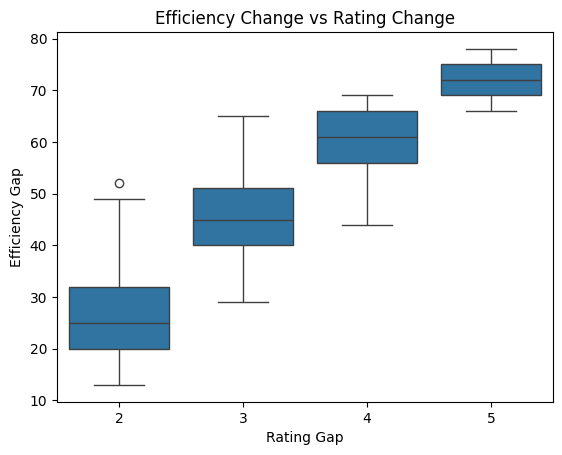

In [ ]:
# Rating vs Efficiency 변화

import seaborn as sns

sns.boxplot(
    x=change.loc[eff_change.index]["rating_gap"],
    y=eff_change["eff_gap"]
)
plt.xlabel("Rating Gap")
plt.ylabel("Efficiency Gap")
plt.title("Efficiency Change vs Rating Change")
plt.show()

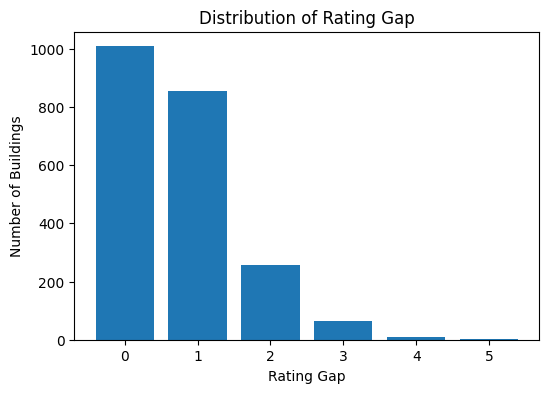

In [41]:
# rating gap 분포

import matplotlib.pyplot as plt

gap_counts = change["rating_gap"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(gap_counts.index, gap_counts.values)

plt.xlabel("Rating Gap")
plt.ylabel("Number of Buildings")
plt.title("Distribution of Rating Gap")

plt.show()

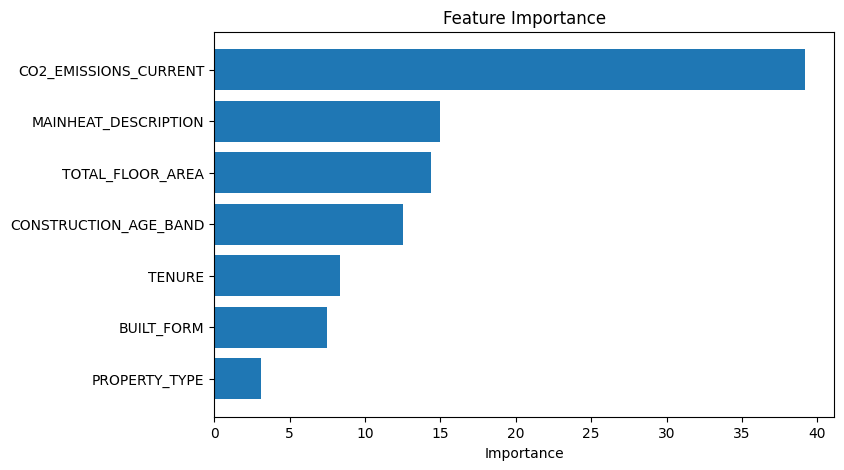

In [42]:
# 피쳐 중요도 

plt.figure(figsize=(8,5))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel("Importance")
plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

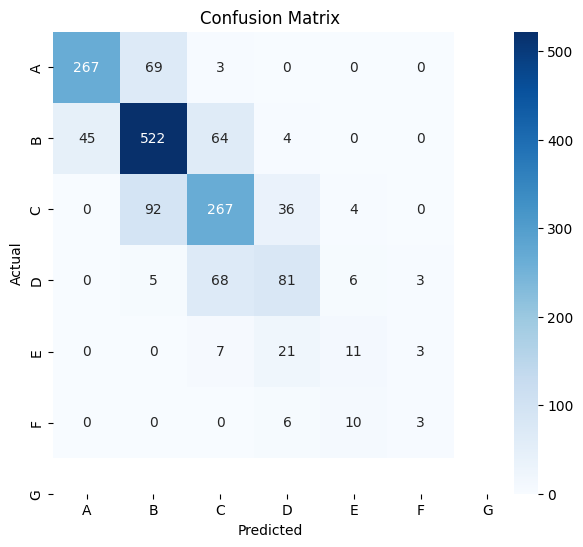

In [43]:
# actual vs pred 비교

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred2)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# 7. Hidden inefficiency 

In [44]:
rating_map = {
    "A": 7,
    "B": 6,
    "C": 5,
    "D": 4,
    "E": 3,
    "F": 2,
    "G": 1
}

result["actual_score"] = result["actual"].map(rating_map)
result["pred_score"] = result["pred"].map(rating_map)

In [47]:
# inefficiency gap check

result["inefficiency_gap"] = (
    result["pred_score"] - result["actual_score"]
)

In [49]:
# inefficiency gap이 2 이상인 real 후보 체크

hidden = result[result["inefficiency_gap"] >= 2]

hidden.head(20)

,TOTAL_FLOOR_AREA,CO2_EMISSIONS_CURRENT,PROPERTY_TYPE,BUILT_FORM,CONSTRUCTION_AGE_BAND,TENURE,MAINHEAT_DESCRIPTION,actual,pred,match,actual_score,pred_score,inefficiency_gap
14811,185.53,5.4,House,Mid-Terrace,England and Wales: 2007 onwards,rental (private),Electric underfloor heating,E,C,False,3,5,2
18264,113.13,5.4,Flat,End-Terrace,England and Wales: 1967-1975,rental (private),Electric underfloor heating,F,D,False,2,4,2
14324,93.00,7.7,Flat,Mid-Terrace,England and Wales: before 1900,owner-occupied,Electric underfloor heating,G,E,False,1,3,2
22523,65.00,1.1,Flat,Not Recorded,England and Wales: 1983-1990,Rented (private),"Boiler and underfloor heating, electric",E,C,False,3,5,2
19687,93.92,6.2,Maisonette,NO DATA!,England and Wales: 1967-1975,rental (private),Electric underfloor heating,F,D,False,2,4,2
15864,52.98,2.7,Flat,Enclosed Mid-Terrace,England and Wales: before 1900,rental (private),"Boiler and radiators, mains gas",F,D,False,2,4,2
21711,40.00,3.2,Flat,Mid-Terrace,England and Wales: 1900-1929,Owner-occupied,"Boiler and radiators, electric",F,D,False,2,4,2
16395,115.66,6.0,Flat,Semi-Detached,England and Wales: 1967-1975,owner-occupied,Electric underfloor heating,F,D,False,2,4,2
22483,57.00,1.5,Flat,Not Recorded,England and Wales: 1967-1975,Owner-occupied,Electric storage heaters,E,C,False,3,5,2
14096,58.00,5.9,Flat,Mid-Terrace,England and Wales: 1930-1949,owner-occupied,"Boiler and radiators, electric",G,E,False,1,3,2


모델 기준으로는 정상 범주에 가까운 건물들이 EPC에서는 과도하게 낮게 평가되는 사례가 존재한다... 왜지?

In [50]:
# anomaly 유형별 빈도 확인

hidden["MAINHEAT_DESCRIPTION"].value_counts().head(10)

MAINHEAT_DESCRIPTION
Electric underfloor heating                10
Community scheme                            3
Boiler and radiators, electric              2
Boiler and underfloor heating, electric     1
Boiler and radiators, mains gas             1
Electric storage heaters                    1
Name: count, dtype: int64

EPC 시스템이 electric heating에 불리 -> 가능성이 가장 큼.

영국 EPC는 historically:

- gas boiler 선호
- electric heating 불리 평가

경향 있음. "특정 난방 시스템(electric-based heating)을 사용하는 건물에서 모델 예측 대비 낮은 EPC 등급이 반복적으로 관찰되었다."

anomaly 건물들의 UPRN 중 실제로 rating_gap도 큰 애들 겹치는지 보기 ✓

In [ ]:
hidden[
    "MAINHEAT_DESCRIPTION"
].value_counts().head(10)

MAINHEAT_DESCRIPTION
Electric underfloor heating                10
Community scheme                            3
Boiler and radiators, electric              2
Boiler and underfloor heating, electric     1
Boiler and radiators, mains gas             1
Electric storage heaters                    1
Name: count, dtype: int64

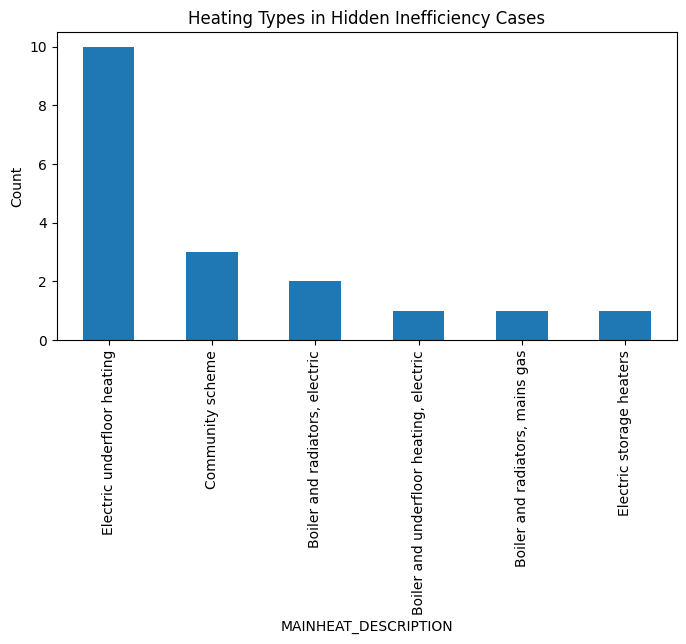

In [ ]:
hidden[
    "MAINHEAT_DESCRIPTION"
].value_counts().head(10).plot.bar(
    figsize=(8,4)
)

plt.title(
    "Heating Types in Hidden Inefficiency Cases"
)

plt.ylabel("Count")

plt.show()

In [51]:
# Hidden inefficiency 후보의 UPRN 찾기

result["UPRN"] = model_df.loc[X_test.index, "UPRN"].values

In [52]:
# Hidden anomaly UPRN 추출

hidden_uprn = result[
    result["inefficiency_gap"] >= 2
]["UPRN"].unique()

len(hidden_uprn)

18

In [53]:
# 모델도 이상 판단 + 실제 등급도 낮은 경우 -> 교집합 체크

weird_uprn = set(weird_uprn)
hidden_uprn = set(hidden_uprn)

overlap = weird_uprn.intersection(hidden_uprn)

len(overlap)


8

In [54]:
# 8개 실제 사례 체크

strong_anomaly = result[result["UPRN"].isin(overlap)].copy()

strong_anomaly.sort_values(
    by="inefficiency_gap",
    ascending=False
)

,TOTAL_FLOOR_AREA,CO2_EMISSIONS_CURRENT,PROPERTY_TYPE,BUILT_FORM,CONSTRUCTION_AGE_BAND,TENURE,MAINHEAT_DESCRIPTION,actual,pred,match,actual_score,pred_score,inefficiency_gap,UPRN
14811,185.53,5.4,House,Mid-Terrace,England and Wales: 2007 onwards,rental (private),Electric underfloor heating,E,C,False,3,5,2,9.550681e+07
14324,93.00,7.7,Flat,Mid-Terrace,England and Wales: before 1900,owner-occupied,Electric underfloor heating,G,E,False,1,3,2,9.550977e+07
22523,65.00,1.1,Flat,Not Recorded,England and Wales: 1983-1990,Rented (private),"Boiler and underfloor heating, electric",E,C,False,3,5,2,9.551346e+07
19687,93.92,6.2,Maisonette,NO DATA!,England and Wales: 1967-1975,rental (private),Electric underfloor heating,F,D,False,2,4,2,2.000001e+11
15864,52.98,2.7,Flat,Enclosed Mid-Terrace,England and Wales: before 1900,rental (private),"Boiler and radiators, mains gas",F,D,False,2,4,2,9.550255e+07
16395,115.66,6.0,Flat,Semi-Detached,England and Wales: 1967-1975,owner-occupied,Electric underfloor heating,F,D,False,2,4,2,2.000001e+11
14096,58.00,5.9,Flat,Mid-Terrace,England and Wales: 1930-1949,owner-occupied,"Boiler and radiators, electric",G,E,False,1,3,2,9.550696e+07
18668,87.00,8.2,Flat,Mid-Terrace,England and Wales: before 1900,owner-occupied,Electric underfloor heating,G,E,False,1,3,2,9.550976e+07
17886,68.00,3.4,Flat,Mid-Terrace,England and Wales: 2003-2006,rental (private),Electric underfloor heating,E,D,False,3,4,1,9.550976e+07


2009-01-28 E -> C

같은 날짜인데:

efficiency 51

efficiency 73

이렇게 달라짐...

동일 시점에서도 상이한 EPC 평가 결과가 존재함

+ 같은 UPRN인데도 built form 계속 흔들림

# Strong anomaly 사례 심층 분석

## Step 1. Strong anomaly UPRN 확인

In [55]:
strong_uprn = list(overlap)

strong_uprn

[np.float64(200000073312.0),
 np.float64(95509765.0),
 np.float64(95509767.0),
 np.float64(95506960.0),
 np.float64(95502547.0),
 np.float64(95513465.0),
 np.float64(200000072988.0),
 np.float64(95506813.0)]

## Step 2. Strong anomaly 전체 기록 보기

In [56]:
strong_history = df_multi[
    df_multi["UPRN"].isin(strong_uprn)
].copy()

strong_history = strong_history.sort_values(
    ["UPRN", "LODGEMENT_DATE"]
)

strong_history[
    [
        "UPRN",
        "LODGEMENT_DATE",
        "CURRENT_ENERGY_RATING",
        "CURRENT_ENERGY_EFFICIENCY",
        "TOTAL_FLOOR_AREA",
        "CO2_EMISSIONS_CURRENT",
        "PROPERTY_TYPE",
        "BUILT_FORM",
        "MAINHEAT_DESCRIPTION"
    ]
]

,UPRN,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,TOTAL_FLOOR_AREA,CO2_EMISSIONS_CURRENT,PROPERTY_TYPE,BUILT_FORM,MAINHEAT_DESCRIPTION
14989,9.550255e+07,2009-02-24,E,45.0,54.70,2.8,Flat,Detached,"Boiler and radiators, electric"
15864,9.550255e+07,2009-05-22,F,28.0,52.98,2.7,Flat,Enclosed Mid-Terrace,"Boiler and radiators, mains gas"
21951,9.550255e+07,2023-06-12,C,76.0,48.00,1.5,Flat,Semi-Detached,"Boiler and radiators, mains gas"
14811,9.550681e+07,2009-01-28,E,51.0,185.53,5.4,House,Mid-Terrace,Electric underfloor heating
19581,9.550681e+07,2009-01-28,C,73.0,185.53,5.9,House,Mid-Terrace,Electric underfloor heating
18992,9.550681e+07,2022-06-14,C,78.0,185.00,6.0,Flat,Enclosed End-Terrace,Electric underfloor heating
13935,9.550696e+07,2008-10-08,E,52.0,57.60,2.5,Flat,Detached,"Boiler and radiators, electric"
14096,9.550696e+07,2020-07-22,G,14.0,58.00,5.9,Flat,Mid-Terrace,"Boiler and radiators, electric"
20184,9.550696e+07,2021-02-17,D,68.0,58.00,2.4,Flat,Mid-Terrace,"Boiler and radiators, electric"
17886,9.550976e+07,2013-10-08,E,53.0,68.00,3.4,Flat,Mid-Terrace,Electric underfloor heating


## Step 2. Case Study #1 시각화

UPRN = 95509767

- 변화폭이 가장 큼
D → G (3단계 하락)

- Efficiency 변화도 극단적
61 → 15

- 면적은 동일
93㎡ → 93㎡

- Heating도 동일
Electric underfloor heating

In [58]:
# UPRN = 95509767

case1 = df_multi[
    df_multi["UPRN"] == 95509767
].copy()

case1 = case1.sort_values("LODGEMENT_DATE")

case1[
    [
        "LODGEMENT_DATE",
        "CURRENT_ENERGY_RATING",
        "CURRENT_ENERGY_EFFICIENCY",
        "TOTAL_FLOOR_AREA",
        "CO2_EMISSIONS_CURRENT",
        "MAINHEAT_DESCRIPTION"
    ]
]

,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,TOTAL_FLOOR_AREA,CO2_EMISSIONS_CURRENT,MAINHEAT_DESCRIPTION
18009,2013-10-08,D,61.0,93.0,3.5,Electric underfloor heating
14324,2016-04-21,G,15.0,93.0,7.7,Electric underfloor heating


- 2013-10-08

D / Efficiency 61 / Area 93 / CO2 3.5

- 2016-04-21

G / Efficiency 15 / Area 93 / CO2 7.7

면적과 난방 방식은 동일한데, efficiency 점수는 61 → 15로 급락했고 등급은 D → G로 3단계 하락함

즉 이 사례는: 건물 물리적 조건보다 평가 입력값 또는 산출 과정의 변화가 등급 변동에 크게 작용했을 가능성

## Step 3. Case Study 시각화

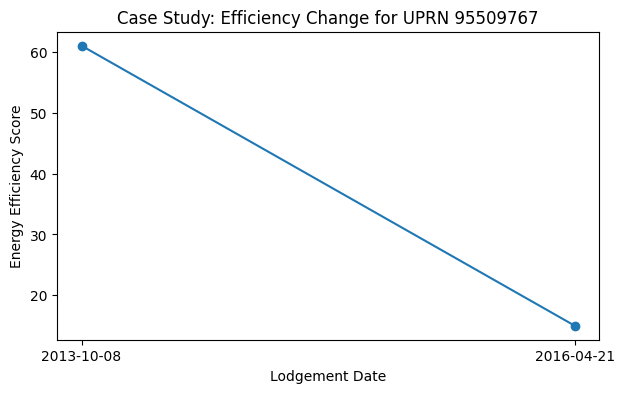

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.plot(
    case1["LODGEMENT_DATE"],
    case1["CURRENT_ENERGY_EFFICIENCY"],
    marker="o"
)

plt.xlabel("Lodgement Date")
plt.ylabel("Energy Efficiency Score")
plt.title("Case Study: Efficiency Change for UPRN 95509767")

plt.show()

In [60]:
# Strong anomaly 8개 요약표

strong_anomaly[
    [
        "UPRN",
        "actual",
        "pred",
        "inefficiency_gap",
        "MAINHEAT_DESCRIPTION"
    ]
].sort_values(
    "inefficiency_gap",
    ascending=False
)

,UPRN,actual,pred,inefficiency_gap,MAINHEAT_DESCRIPTION
14811,9.550681e+07,E,C,2,Electric underfloor heating
14324,9.550977e+07,G,E,2,Electric underfloor heating
22523,9.551346e+07,E,C,2,"Boiler and underfloor heating, electric"
19687,2.000001e+11,F,D,2,Electric underfloor heating
15864,9.550255e+07,F,D,2,"Boiler and radiators, mains gas"
16395,2.000001e+11,F,D,2,Electric underfloor heating
14096,9.550696e+07,G,E,2,"Boiler and radiators, electric"
18668,9.550976e+07,G,E,2,Electric underfloor heating
17886,9.550976e+07,E,D,1,Electric underfloor heating


Strong anomaly = 8개

공통 특징:
- Electric underfloor heating
- Community scheme
- Old buildings